# 🛒 Proyecto PGAD 2026-1
## Notebook 2 — Etapas 3 y 4: Procesamiento Avanzado y EDA

**Flujo de trabajo:**
1. **Etapa 3 (Python):** Cargar desde SQL → limpieza avanzada → feature engineering → exportar CSV para R
2. **Etapa 4 (R):** EDA con visualizaciones estadísticas

> **Prerequisito:** El archivo `Tabla_unificada.sql` generado en el Notebook 1 debe estar disponible en `/content/`.

---
## 🐍 Etapa 3 — Procesamiento Avanzado en Python

In [15]:
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from google.colab import data_table

# ── 1. Cargar datos desde el archivo SQL ──────────────────────────────────────
def load_data_from_sql(sql_file: str) -> pd.DataFrame:
    """Carga datos desde un archivo .sql generado en la Etapa 2."""
    conn = sqlite3.connect(':memory:')
    with open(sql_file, 'r', encoding='utf-8') as f:
        conn.executescript(f.read())

    query = """
    SELECT
        t.*,
        c.age, c.city, c.membership_level,
        c.loyalty_score, c.estimated_income,
        p.category, p.brand
    FROM transactions t
    LEFT JOIN customers c ON t.customer_id = c.customer_id
    LEFT JOIN products  p ON t.product_id  = p.product_id
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

# ⚠️ Ajusta el nombre del archivo si cambiaste el nombre en el Notebook 1
SQL_FILE = 'Tabla_unificada.sql'

df_raw = load_data_from_sql(SQL_FILE)
print(f"✅ Datos cargados desde SQL: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
data_table.enable_dataframe_formatter()
display(df_raw.head(5))

✅ Datos cargados desde SQL: 1069 filas × 21 columnas


,transaction_id,customer_id,product_id,transaction_date,channel,quantity,unit_price,discount_pct,promo_flag,payment_method,...,prior_purchases,total_amount,repeat_purchase_next_month,age,city,membership_level,loyalty_score,estimated_income,category,brand
0,1,19,63,2025-06-08 00:00:00,Store,5,678.65,0.036,0,Debit Card,...,11,3910.59,0,34.0,Bucaramanga,N/A,58.47,3040.67,Electronics,Pulse
1,2,58,18,2025-11-05 00:00:00,Web,1,19.38,0.000,0,Digital Wallet,...,11,13.88,1,30.0,Bucaramanga,Basic,75.19,3616.82,Beauty,Viva
2,3,4,63,2025-10-01 00:00:00,Store,3,723.15,0.060,0,Debit Card,...,12,1804.96,0,36.0,Medellin,Basic,70.27,3233.25,Electronics,Pulse
3,4,152,13,2025-02-06 00:00:00,Web,2,17.59,0.103,0,Digital Wallet,...,8,29.71,1,24.0,Bucaramanga,Platinum,77.55,3502.95,Groceries,Zenit
4,5,70,21,2025-11-25 00:00:00,Store,5,32.33,0.165,0,Digital Wallet,...,13,135.40,0,33.0,Bucaramanga,Silver,67.29,1308.24,Home,Orion


In [16]:
# ── 2. Limpieza avanzada y Feature Engineering ────────────────────────────────

def process_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica limpieza robusta y genera nuevas variables para el análisis.

    Pasos:
        A. Tipos de datos (fechas)
        B. Imputación inteligente por grupo
        C. Estandarización de texto
        D. Feature engineering
    """
    df_clean = df.copy()

    # A — Fechas
    df_clean['transaction_date'] = pd.to_datetime(df_clean['transaction_date'])
    df_clean['year']  = df_clean['transaction_date'].dt.year
    df_clean['month'] = df_clean['transaction_date'].dt.month
    df_clean['quarter'] = df_clean['transaction_date'].dt.quarter

    # B — Imputación inteligente
    # Ingresos: mediana por nivel de membresía
    df_clean['estimated_income'] = df_clean.groupby('membership_level')['estimated_income'].transform(
        lambda x: x.fillna(x.median())
    )
    # Edad y loyalty_score: mediana global
    df_clean['age']           = df_clean['age'].fillna(df_clean['age'].median())
    df_clean['loyalty_score'] = df_clean['loyalty_score'].fillna(df_clean['loyalty_score'].median())

    # Variables de texto
    cols_texto = ['city', 'membership_level', 'category', 'brand', 'channel', 'payment_method']
    df_clean[cols_texto] = df_clean[cols_texto].fillna('Desconocido')

    # C — Estandarización
    for col in cols_texto:
        df_clean[col] = df_clean[col].str.strip().str.title()

    # D — Feature Engineering
    # Valor promedio por ítem
    df_clean['avg_item_value'] = df_clean['total_amount'] / df_clean['quantity'].replace(0, 1)

    # Recencia: compra reciente (≤30 días)
    df_clean['is_recent_customer'] = np.where(df_clean['days_since_last_purchase'] <= 30, 1, 0)

    # Segmento de gasto
    q33 = df_clean['total_amount'].quantile(0.33)
    q66 = df_clean['total_amount'].quantile(0.66)
    df_clean['spending_segment'] = pd.cut(
        df_clean['total_amount'],
        bins=[-np.inf, q33, q66, np.inf],
        labels=['Bajo', 'Medio', 'Alto']
    )

    # Descuento efectivo aplicado
    df_clean['effective_discount'] = df_clean['unit_price'] * df_clean['discount_pct'] / 100

    return df_clean

df_final = process_data(df_raw)

print("✅ Procesamiento completado.")
print(f"   Columnas originales: {df_raw.shape[1]} → Columnas finales: {df_final.shape[1]}")
print(f"   Nulos restantes: {df_final.isnull().sum().sum()}")
display(df_final.dtypes.to_frame('dtype'))

✅ Procesamiento completado.
   Columnas originales: 21 → Columnas finales: 28
   Nulos restantes: 0


,dtype
transaction_id,int64
customer_id,int64
product_id,int64
transaction_date,datetime64[ns]
channel,object
quantity,int64
unit_price,float64
discount_pct,float64
promo_flag,int64
payment_method,object


In [17]:
# ── 3. Visualizaciones — Análisis de Features Creadas ─────────────────────────

# Panel A: Segmento de gasto + cliente reciente
fig_a = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "domain"}]],
    subplot_titles=[
        'Distribución por Segmento de Gasto',
        'Clientes Recientes vs No Recientes'
    ]
)

seg = df_final['spending_segment'].value_counts().reset_index()
seg.columns = ['spending_segment', 'count']
fig_a.add_trace(
    go.Bar(
        x=seg['spending_segment'], y=seg['count'],
        marker_color=['#a8d8ea', '#aa96da', '#fcbad3'],
        text=seg['count'], textposition='outside'
    ),
    row=1, col=1
)

rec = df_final['is_recent_customer'].value_counts().rename({0: 'No Reciente', 1: 'Reciente'}).reset_index()
rec.columns = ['tipo', 'count']
fig_a.add_trace(
    go.Pie(
        labels=rec['tipo'], values=rec['count'],
        marker_colors=['#f9ca24', '#6ab04c'],
        hole=0.35, textinfo='label+percent'
    ),
    row=1, col=2
)

fig_a.update_layout(
    title_text='🧩 Features Creadas — Segmento de Gasto y Recencia',
    height=420, showlegend=False
)
fig_a.show()

# Panel B: avg_item_value por categoría + ingreso estimado por membresía
fig_b = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Valor Promedio por Ítem (por Categoría)',
        'Ingreso Estimado Promedio por Nivel de Membresía'
    ]
)

aiv = df_final.groupby('category')['avg_item_value'].mean().reset_index().sort_values('avg_item_value', ascending=True)
fig_b.add_trace(
    go.Bar(
        x=aiv['avg_item_value'], y=aiv['category'],
        orientation='h',
        marker_color=px.colors.sequential.Blues_r[:len(aiv)],
        text=aiv['avg_item_value'].map('${:.1f}'.format),
        textposition='outside'
    ),
    row=1, col=1
)

inc = df_final.groupby('membership_level')['estimated_income'].mean().reset_index()
fig_b.add_trace(
    go.Bar(
        x=inc['membership_level'], y=inc['estimated_income'],
        marker_color=px.colors.qualitative.Prism[:len(inc)],
        text=inc['estimated_income'].map('${:,.0f}'.format),
        textposition='outside'
    ),
    row=1, col=2
)

fig_b.update_layout(
    title_text='💡 Análisis por Categoría y Nivel de Membresía',
    height=420, showlegend=False
)
fig_b.show()

# Temporal: ventas por mes
monthly = df_final.groupby(['year', 'month'])['total_amount'].sum().reset_index()
monthly['periodo'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

fig_c = px.line(
    monthly, x='periodo', y='total_amount',
    title='📅 Evolución de Ventas Totales por Mes',
    labels={'total_amount': 'Ventas ($)', 'periodo': 'Mes'},
    markers=True, line_shape='spline'
)
fig_c.update_traces(line_color='steelblue', marker_color='tomato', marker_size=8)
fig_c.update_layout(height=380, xaxis_tickangle=-45)
fig_c.show()

In [18]:
# ── 4. Exportar CSV para R ────────────────────────────────────────────────────
OUTPUT_CSV = 'datos_procesados_para_R.csv'
df_final.to_csv(OUTPUT_CSV, index=False)

print(f"✅ Etapa 3 completada.")
print(f"   Archivo '{OUTPUT_CSV}' listo para la Etapa 4 (R).")
print(f"   Shape: {df_final.shape}")
display(df_final.head(5))

✅ Etapa 3 completada.
   Archivo 'datos_procesados_para_R.csv' listo para la Etapa 4 (R).
   Shape: (1069, 28)


,transaction_id,customer_id,product_id,transaction_date,channel,quantity,unit_price,discount_pct,promo_flag,payment_method,...,estimated_income,category,brand,year,month,quarter,avg_item_value,is_recent_customer,spending_segment,effective_discount
0,1,19,63,2025-06-08,Store,5,678.65,0.036,0,Debit Card,...,3040.67,Electronics,Pulse,2025,6,2,782.118000,0,Alto,0.244314
1,2,58,18,2025-11-05,Web,1,19.38,0.000,0,Digital Wallet,...,3616.82,Beauty,Viva,2025,11,4,13.880000,0,Bajo,0.000000
2,3,4,63,2025-10-01,Store,3,723.15,0.060,0,Debit Card,...,3233.25,Electronics,Pulse,2025,10,4,601.653333,1,Alto,0.433890
3,4,152,13,2025-02-06,Web,2,17.59,0.103,0,Digital Wallet,...,3502.95,Groceries,Zenit,2025,2,1,14.855000,0,Bajo,0.018118
4,5,70,21,2025-11-25,Store,5,32.33,0.165,0,Digital Wallet,...,1308.24,Home,Orion,2025,11,4,27.080000,1,Medio,0.053345


---
## 📊 Etapa 4 — EDA en R

> Las celdas siguientes usan la magia `%%R` de `rpy2`. Asegúrate de que `rpy2` esté instalado en Colab (viene preinstalado normalmente).

In [14]:
# Activar el puente Python ↔ R
!apt-get update -qq
!apt-get install -y r-base
!pip install rpy2

%load_ext rpy2.ipython

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  r-base-core r-recommended
Suggested packages:
  elpa-ess r-doc-info | r-doc-pdf r-mathlib r-base-html
Recommended packages:
  r-base-html r-doc-html
The following packages will be upgraded:
  r-base r-base-core r-recommended
3 upgraded, 0 newly installed, 0 to remove and 72 not upgraded.
Need to get 30.3 MB of archives.
After this operation, 1,509 kB of additional disk space will be used.
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ r-base-core 4.6.0-2.2204.4 [30.3 MB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ r-base 4.6.0-2.2204.4 [47.9 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ r-r

In [19]:
%%R
# ── Librerías R ───────────────────────────────────────────────────────────────
# Instala si no están disponibles en el entorno de Colab
if (!require('ggplot2',    quietly=TRUE)) install.packages('ggplot2')
if (!require('dplyr',     quietly=TRUE)) install.packages('dplyr')
if (!require('tidyr',     quietly=TRUE)) install.packages('tidyr')
if (!require('scales',    quietly=TRUE)) install.packages('scales')
if (!require('ggcorrplot',quietly=TRUE)) install.packages('ggcorrplot')
if (!require('viridis',   quietly=TRUE)) install.packages('viridis')

library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)
library(ggcorrplot)
library(viridis)

cat("✅ Librerías R cargadas correctamente\n")

✅ Librerías R cargadas correctamente


In [20]:
%%R
# ── Carga de datos ────────────────────────────────────────────────────────────
df <- read.csv('datos_procesados_para_R.csv', stringsAsFactors = FALSE)
df$transaction_date <- as.Date(df$transaction_date)

cat(sprintf('Filas: %d | Columnas: %d\n', nrow(df), ncol(df)))
cat('\nPrimeras filas:\n')
print(head(df, 3))
cat('\nResumen estadístico:\n')
print(summary(df[, c('total_amount', 'age', 'loyalty_score', 'estimated_income')]))

Filas: 1069 | Columnas: 28

Primeras filas:
  transaction_id customer_id product_id transaction_date channel quantity
1              1          19         63       2025-06-08   Store        5
2              2          58         18       2025-11-05     Web        1
3              3           4         63       2025-10-01   Store        3
  unit_price discount_pct promo_flag payment_method days_since_last_purchase
1     678.65        0.036          0     Debit Card                       48
2      19.38        0.000          0 Digital Wallet                       45
3     723.15        0.060          0     Debit Card                        5
  prior_purchases total_amount repeat_purchase_next_month age        city
1              11      3910.59                          0  34 Bucaramanga
2              11        13.88                          1  30 Bucaramanga
3              12      1804.96                          0  36    Medellin
  membership_level loyalty_score estimated_income    cat

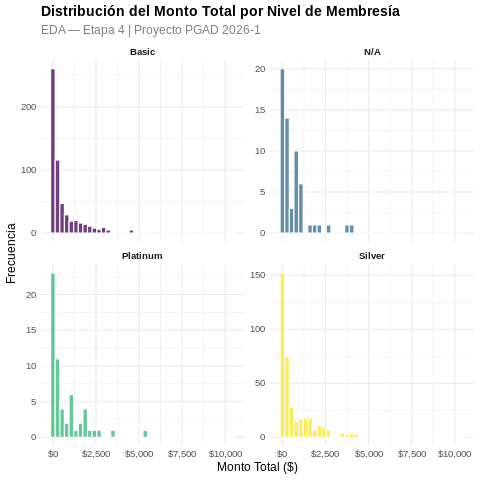

In [21]:
%%R
# ── Gráfico 1: Distribución de total_amount por membresía ─────────────────────
options(repr.plot.width=10, repr.plot.height=5)

ggplot(df, aes(x = total_amount, fill = membership_level)) +
  geom_histogram(bins = 40, alpha = 0.75, position = 'identity', color = 'white') +
  facet_wrap(~ membership_level, scales = 'free_y') +
  scale_x_continuous(labels = dollar_format()) +
  scale_fill_viridis_d(option = 'D') +
  labs(
    title    = 'Distribución del Monto Total por Nivel de Membresía',
    subtitle = 'EDA — Etapa 4 | Proyecto PGAD 2026-1',
    x = 'Monto Total ($)',
    y = 'Frecuencia',
    fill = 'Membresía'
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title    = element_text(face = 'bold', size = 14),
    plot.subtitle = element_text(color = 'gray50'),
    legend.position = 'none',
    strip.text = element_text(face = 'bold')
  )

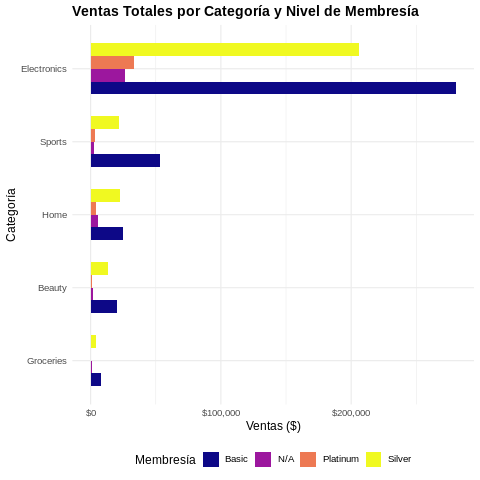

In [22]:
%%R
# ── Gráfico 2: Ventas totales por categoría y nivel de membresía ──────────────
options(repr.plot.width=10, repr.plot.height=5)

df_cat <- df %>%
  group_by(category, membership_level) %>%
  summarise(ventas = sum(total_amount, na.rm=TRUE), .groups='drop')

ggplot(df_cat, aes(x = reorder(category, ventas), y = ventas, fill = membership_level)) +
  geom_col(position = 'dodge', width = 0.7) +
  coord_flip() +
  scale_y_continuous(labels = dollar_format(big.mark=',')) +
  scale_fill_viridis_d(option = 'C') +
  labs(
    title  = 'Ventas Totales por Categoría y Nivel de Membresía',
    x      = 'Categoría',
    y      = 'Ventas ($)',
    fill   = 'Membresía'
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title    = element_text(face='bold', size=14),
    legend.position = 'bottom'
  )

`geom_smooth()` using formula = 'y ~ x'


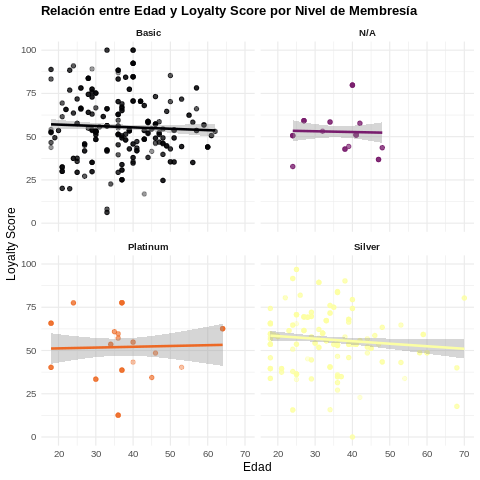

In [23]:
%%R
# ── Gráfico 3: Relación Edad vs Loyalty Score (por membresía) ─────────────────
options(repr.plot.width=9, repr.plot.height=5)

ggplot(df, aes(x = age, y = loyalty_score, color = membership_level)) +
  geom_point(alpha = 0.4, size = 1.8) +
  geom_smooth(method = 'lm', se = TRUE, linewidth = 1.2) +
  facet_wrap(~ membership_level) +
  scale_color_viridis_d(option = 'B') +
  labs(
    title    = 'Relación entre Edad y Loyalty Score por Nivel de Membresía',
    x        = 'Edad',
    y        = 'Loyalty Score',
    color    = 'Membresía'
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title    = element_text(face='bold', size=13),
    legend.position = 'none',
    strip.text = element_text(face='bold')
  )

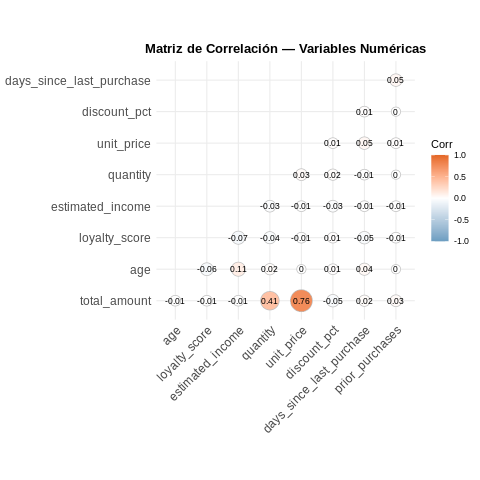

In [24]:
%%R
# ── Gráfico 4: Matriz de correlación de variables numéricas ───────────────────
options(repr.plot.width=8, repr.plot.height=7)

vars_num <- df %>%
  select(total_amount, age, loyalty_score, estimated_income,
         quantity, unit_price, discount_pct, days_since_last_purchase,
         prior_purchases) %>%
  drop_na()

cor_mat <- cor(vars_num, use='complete.obs')

ggcorrplot(
  cor_mat,
  method   = 'circle',
  type     = 'lower',
  lab      = TRUE,
  lab_size = 3,
  colors   = c('#6D9EC1', 'white', '#E46726'),
  title    = 'Matriz de Correlación — Variables Numéricas',
  ggtheme  = theme_minimal(base_size = 11)
) +
  theme(plot.title = element_text(face='bold', size=13, hjust=0.5))

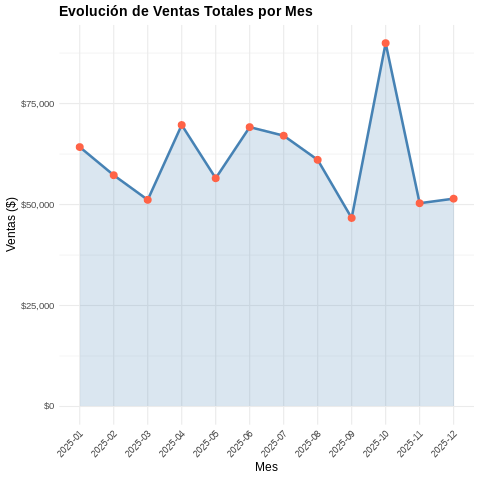

In [25]:
%%R
# ── Gráfico 5: Evolución mensual de ventas ────────────────────────────────────
options(repr.plot.width=11, repr.plot.height=5)

df$mes <- format(df$transaction_date, '%Y-%m')

ventas_mes <- df %>%
  group_by(mes) %>%
  summarise(
    ventas_totales = sum(total_amount, na.rm=TRUE),
    n_transacciones = n(),
    .groups='drop'
  ) %>%
  arrange(mes)

ggplot(ventas_mes, aes(x = mes, y = ventas_totales, group = 1)) +
  geom_area(fill='steelblue', alpha=0.2) +
  geom_line(color='steelblue', linewidth=1.2) +
  geom_point(color='tomato', size=3) +
  scale_y_continuous(labels = dollar_format(big.mark=',')) +
  labs(
    title  = 'Evolución de Ventas Totales por Mes',
    x      = 'Mes',
    y      = 'Ventas ($)'
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x   = element_text(angle=45, hjust=1, size=9),
    plot.title    = element_text(face='bold', size=14)
  )

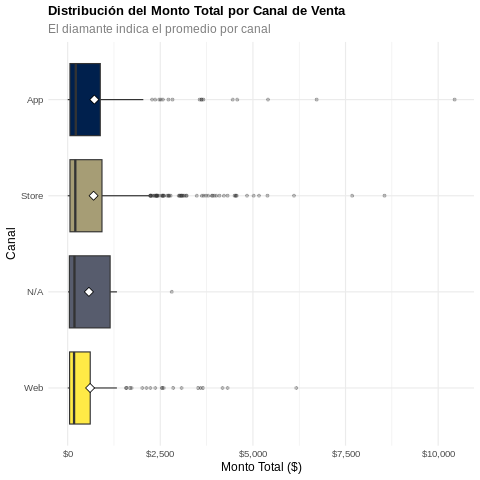

In [26]:
%%R
# ── Gráfico 6: Boxplot de total_amount por canal de venta ─────────────────────
options(repr.plot.width=9, repr.plot.height=5)

ggplot(df, aes(x = reorder(channel, total_amount, FUN=median), y = total_amount, fill = channel)) +
  geom_boxplot(outlier.alpha=0.3, outlier.size=1.2, notch=FALSE) +
  stat_summary(fun=mean, geom='point', shape=23, size=3, fill='white', color='black') +
  coord_flip() +
  scale_y_continuous(labels = dollar_format()) +
  scale_fill_viridis_d(option='E') +
  labs(
    title    = 'Distribución del Monto Total por Canal de Venta',
    subtitle = 'El diamante indica el promedio por canal',
    x        = 'Canal',
    y        = 'Monto Total ($)'
  ) +
  theme_minimal(base_size=12) +
  theme(
    legend.position='none',
    plot.title    = element_text(face='bold', size=13),
    plot.subtitle = element_text(color='gray50')
  )